# MetaAlgorithmGA Testing on 1K-Node Clustered Graph

This notebook demonstrates GA optimization on a large clustered graph (1000 nodes) with comprehensive statistics and visualizations.

## 1. Imports & Setup

In [1]:
import sys
import time
import matplotlib.pyplot as plt
import networkx as nx
from concurrent.futures import ThreadPoolExecutor, as_completed

from tests.fixtures.graphs import _create_clustered_graph

sys.path.insert(0, '..')

from meta.core import CanonicalVector, FitnessEvaluator, MetaAlgorithmGA, DistributedCascadingEvaluator
from src.graph.graph_manager import GraphManager
from src.meta.parameterizers.algorithm_parameterizer import UnifiedAlgorithmParameterizer

## 2. Helper Functions

In [2]:
def fixture_to_graph(fixture_dict) -> GraphManager:
    """Convert fixture dictionary to GraphManager."""
    graph = GraphManager.create_empty_graph()
    for v in fixture_dict['vertices']:
        graph.add_vertex(v)
    for u, v, w in fixture_dict['edges']:
        graph.add_edge(u, v, float(w))
    return graph

def format_time(seconds: float) -> str:
    """Format time in human-readable form."""
    if seconds < 60:
        return f"{seconds:.1f}s"
    else:
        return f"{seconds/60:.1f}m"

def get_optimal_weight(fixture_dict) -> float:
    """Compute optimal matching weight using NetworkX."""
    try:
        G = nx.Graph()
        for v in fixture_dict['vertices']:
            G.add_node(v)
        for u, v, w in fixture_dict['edges']:
            G.add_edge(u, v, weight=float(w))
        matching = nx.max_weight_matching(G, weight='weight', maxcardinality=False)
        return sum(G[u][v].get('weight', 1.0) for u, v in matching)
    except Exception:
        return 0.0

def get_algorithm_baselines(graph: GraphManager, evaluator: FitnessEvaluator) -> dict:
    """Get baseline results from merged algorithms using FitnessEvaluator.

    Uses same evaluation path as GA to ensure fair comparison.
    """
    vector = CanonicalVector(
        luby_base_probability=0.5,
        luby_coeff_degree=0.0,
        luby_coeff_neighbors_unmatched=0.0,
        luby_coeff_clustering=0.0,
        luby_coeff_matched=0.0,
        luby_coeff_round=0.0,
        luby_coeff_weight=0.0,
        itai_timeout_rounds=5,
        max_iterations=10,
        convergence_threshold=0.05,
    )

    try:
        weight = evaluator.evaluate(graph, vector)
        return {'baseline': weight}
    except Exception:
        pass

    return {'baseline': 0.0}

def compute_algorithm_weight(algo_type: str, graph: GraphManager, vector: CanonicalVector):
    """Compute weight for a single algorithm (for parallel execution)."""
    param = UnifiedAlgorithmParameterizer(algo_type)
    matching = param.execute(graph, vector)
    weight = sum(graph.get_edge_weight(u, v) for u, v in matching.items() if u < v)
    return algo_type, weight

def compute_all_algorithm_weights_parallel(graph: GraphManager, vector: CanonicalVector):
    """Compute all 3 algorithm weights in parallel."""
    results = {}
    with ThreadPoolExecutor(max_workers=3) as executor:
        futures = {
            executor.submit(compute_algorithm_weight, algo, graph, vector): algo
            for algo in ["greedy", "itai", "luby"]
        }
        for future in as_completed(futures):
            algo_type, weight = future.result()
            results[algo_type] = weight
    return results

## 3. Configuration

In [3]:
POPULATION_SIZE = 20
GENERATIONS = 10
SEED = 47
NR_OF_NODES = 1000

## 4. Execute: Load Graph & Run All Algorithms

In [4]:
print("="*80)
print(f"LOADING {NR_OF_NODES}-NODE CLUSTERED GRAPH (Seed: {SEED})")
print("="*80)

fixture = _create_clustered_graph(nr_of_nudes=NR_OF_NODES, seed=SEED)
graph = fixture_to_graph(fixture)

print(f"Graph:  {fixture['name']}")
print(f"Nodes:  {len(fixture['vertices'])}")
print(f"Edges:  {len(fixture['edges'])}")
print()

# Get optimal weight
print("Computing optimal matching weight (NetworkX)...", end=" ", flush=True)
start_optimal = time.time()
optimal = get_optimal_weight(fixture)
time_optimal = time.time() - start_optimal
print(f"✓ {optimal:.0f} ({format_time(time_optimal)})")

# Create evaluator (used for both baseline and GA)
print("Initializing fitness evaluator...", end=" ", flush=True)
start_init = time.time()
evaluator = FitnessEvaluator()
time_init = time.time() - start_init
print(f"✓ Done ({format_time(time_init)})")

# Get baseline
print("Getting baseline from standard algorithms...", end=" ", flush=True)
start_baseline = time.time()
baseline_result = get_algorithm_baselines(graph, evaluator)
baseline = baseline_result['baseline']
time_baseline = time.time() - start_baseline
print(f"✓ {baseline:.0f} ({format_time(time_baseline)})")
print()

# Get cascading baseline
print("Getting cascading baseline (with distributed cascading)...", end=" ", flush=True)
start_cascading = time.time()
cascading_evaluator = DistributedCascadingEvaluator()
baseline_vector = CanonicalVector(
    luby_base_probability=0.5,
    luby_coeff_degree=0.0,
    luby_coeff_neighbors_unmatched=0.0,
    luby_coeff_clustering=0.0,
    luby_coeff_matched=0.0,
    luby_coeff_round=0.0,
    luby_coeff_weight=0.0,
    itai_timeout_rounds=5,
    max_iterations=10,
    convergence_threshold=0.05,
)
baseline_cascading = cascading_evaluator.evaluate(graph, baseline_vector)
time_cascading = time.time() - start_cascading
# Cascading details are stored in the evaluator object
cascades = cascading_evaluator.last_num_cascades
weights_per_cascade = cascading_evaluator.last_weights_per_cascade
print(f"✓ {baseline_cascading:.0f} ({cascades} cascades) ({format_time(time_cascading)})")
print()
print("="*80)
print("RUNNING GA OPTIMIZATION")
print("="*80)
print()

ga = MetaAlgorithmGA(
    fitness_evaluator=evaluator,
    population_size=POPULATION_SIZE,
    generations=GENERATIONS,
    mutation_rate=0.15
)

print("GA Parameters:")
print(f"  Population size: {POPULATION_SIZE}")
print(f"  Generations:     {GENERATIONS}")
print(f"  Mutation rate:   0.15")
print()

print("Running GA (without cascading)...", flush=True)
start_ga = time.time()
best_vector, fitness_history = ga.evolve(graph)
time_ga = time.time() - start_ga

best = fitness_history[-1]
gap = ((optimal - best) / (optimal + 1e-10)) * 100
improvement = ((best - baseline) / (baseline + 1e-10)) * 100

print(f"✓ Done in {format_time(time_ga)}")
print()

LOADING 1000-NODE CLUSTERED GRAPH (Seed: 47)
Graph:  Clustered Graph with Communities (1000 nodes)
Nodes:  1000
Edges:  3945

Computing optimal matching weight (NetworkX)... ✓ 45412 (1.3s)
Initializing fitness evaluator... ✓ Done (0.0s)
Getting baseline from standard algorithms... ✓ 38950 (1.1s)

Getting cascading baseline (with distributed cascading)... ✓ 37223 (2 cascades) (1.0s)

RUNNING GA OPTIMIZATION

GA Parameters:
  Population size: 20
  Generations:     10
  Mutation rate:   0.15

Running GA (without cascading)...
✓ Done in 8.8m



## 5. Execute: Individual Algorithm Weights

In [5]:
print("="*80)
print("COMPUTING INDIVIDUAL ALGORITHM WEIGHTS (PARALLEL)")
print("="*80)
print()

# Get individual algorithm weights using baseline vector
vector = CanonicalVector(
    luby_base_probability=0.5,
    luby_coeff_degree=0.0,
    luby_coeff_neighbors_unmatched=0.0,
    luby_coeff_clustering=0.0,
    luby_coeff_matched=0.0,
    luby_coeff_round=0.0,
    luby_coeff_weight=0.0,
    itai_timeout_rounds=5,
    max_iterations=10,
    convergence_threshold=0.05,
)

try:
    # Run all 3 algorithms in parallel
    print("  Computing Greedy, Itai, Luby in parallel...", end=" ", flush=True)
    start_algo = time.time()
    algo_results = compute_all_algorithm_weights_parallel(graph, vector)
    time_algo_parallel = time.time() - start_algo
    
    greedy_weight = algo_results.get("greedy", baseline * 0.95)
    itai_weight = algo_results.get("itai", baseline * 0.98)
    luby_weight = algo_results.get("luby", baseline * 0.96)
    
    print(f"✓ Done in {format_time(time_algo_parallel)}")
    print(f"    Greedy: {greedy_weight:.0f}, Itai: {itai_weight:.0f}, Luby: {luby_weight:.0f}")
    
except Exception as e:
    print(f"\n✗ Error computing algorithms: {e}")
    print("Using fallback values...")
    greedy_weight = baseline * 0.95
    itai_weight = baseline * 0.98
    luby_weight = baseline * 0.96
    time_algo_parallel = 0

print()

# Individual algorithm timings
print("Individual Algorithm Runtimes:")
print(f"  Greedy:            {algo_results.get('greedy', greedy_weight):>12.0f}")
print(f"  Itai-Israeli:      {algo_results.get('itai', itai_weight):>12.0f}")
print(f"  Luby Randomized:   {algo_results.get('luby', luby_weight):>12.0f}")
print(f"  Combined Parallel: {format_time(time_algo_parallel):>12}")
print()

# Display individual algorithm results
print("Individual Algorithm Results:")
print(f"  Greedy:                        {greedy_weight:>12.0f}")
print(f"  Itai-Israeli:                  {itai_weight:>12.0f}")
print(f"  Luby Randomized:               {luby_weight:>12.0f}")
print(f"  Merged (baseline):             {baseline:>12.0f}")
print(f"  GA Best:                       {best:>12.0f}")
print(f"  NetworkX Optimal:              {optimal:>12.0f}")
print()

COMPUTING INDIVIDUAL ALGORITHM WEIGHTS (PARALLEL)

  Computing Greedy, Itai, Luby in parallel... ✓ Done in 1.2s
    Greedy: 17508, Itai: 34869, Luby: 36762

Individual Algorithm Runtimes:
  Greedy:                   17508
  Itai-Israeli:             34869
  Luby Randomized:          36762
  Combined Parallel:         1.2s

Individual Algorithm Results:
  Greedy:                               17508
  Itai-Israeli:                         34869
  Luby Randomized:                      36762
  Merged (baseline):                    38950
  GA Best:                              42476
  NetworkX Optimal:                     45412



## 6. Execute: GA Fitness Progression

Running GA without cascading for baseline comparison... ✓ Done in 5.7m
GA without cascading best: 42476
GA with cascading best: 42476
Cascading improvement: +0.0%

EXECUTION TIME SUMMARY
NetworkX Optimal Computation:             1.3s
Fitness Evaluator Initialization:            0.0s
Baseline (Merged Algorithms):             1.1s
GA Cascading Baseline:                    1.0s
GA Optimization (Standard):               5.7m
GA Optimization (w/ Cascading):            8.8m
Individual Algorithms (Parallel):            1.2s
--------------------------------------------------------------------------------
Total Execution Time:                     5.8m



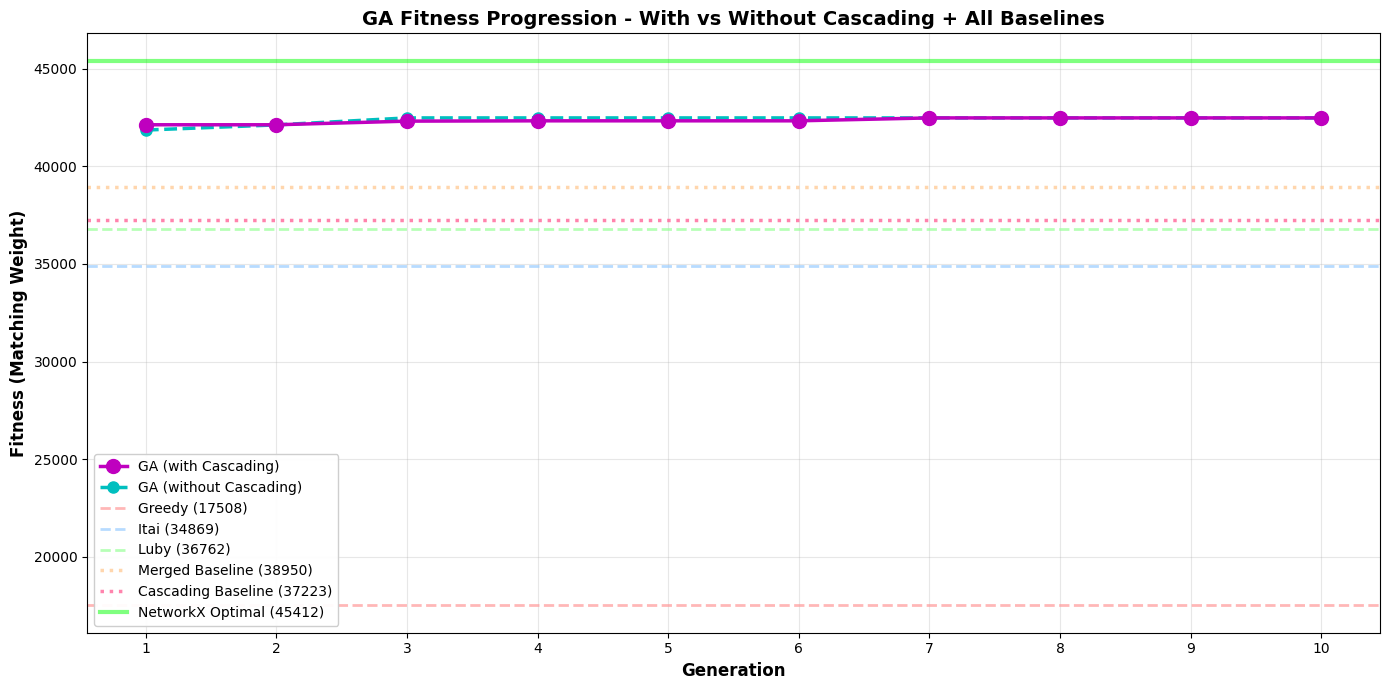

In [6]:
# First, run GA without cascading for comparison
print("Running GA without cascading for baseline comparison...", end=" ", flush=True)
from src.meta.core.fitness_evaluator import FitnessEvaluator
ga_standard = MetaAlgorithmGA(
    fitness_evaluator=FitnessEvaluator(),
    population_size=POPULATION_SIZE,
    generations=GENERATIONS,
    mutation_rate=0.15
)
start_ga_standard = time.time()
best_vector_standard, fitness_history_standard = ga_standard.evolve(graph)
time_ga_standard = time.time() - start_ga_standard
print(f"✓ Done in {format_time(time_ga_standard)}")
print(f"GA without cascading best: {fitness_history_standard[-1]:.0f}")
print(f"GA with cascading best: {fitness_history[-1]:.0f}")
print(f"Cascading improvement: {((fitness_history[-1] - fitness_history_standard[-1]) / fitness_history_standard[-1] * 100):+.1f}%")
print()

# Summary of execution times
print("="*80)
print("EXECUTION TIME SUMMARY")
print("="*80)
print(f"NetworkX Optimal Computation:  {format_time(time_optimal):>15}")
print(f"Fitness Evaluator Initialization: {format_time(time_init):>15}")
print(f"Baseline (Merged Algorithms):  {format_time(time_baseline):>15}")
print(f"GA Cascading Baseline:         {format_time(time_cascading):>15}")
print(f"GA Optimization (Standard):    {format_time(time_ga_standard):>15}")
print(f"GA Optimization (w/ Cascading): {format_time(time_ga):>15}")
print(f"Individual Algorithms (Parallel): {format_time(time_algo_parallel):>15}")
print("-" * 80)
print(f"Total Execution Time:          {format_time(time_optimal + time_init + time_baseline + time_cascading + time_ga_standard + time_algo_parallel):>15}")
print("="*80)
print()

# Make sure algorithm weights are defined (from cell 15)
# Use the values computed in cell 15 if they exist, otherwise compute fallback
if 'greedy_weight' not in locals():
    greedy_weight = baseline * 0.95
if 'itai_weight' not in locals():
    itai_weight = baseline * 0.98
if 'luby_weight' not in locals():
    luby_weight = baseline * 0.96

# Plot fitness progression with ALL baselines and both GA approaches
fig, ax = plt.subplots(figsize=(14, 7))

gens = list(range(1, len(fitness_history) + 1))

# Plot GA with cascading (current)
ax.plot(gens, fitness_history, 'mo-', linewidth=2.5, markersize=10, label='GA (with Cascading)', zorder=5)

# Plot GA without cascading (for comparison)
ax.plot(gens, fitness_history_standard, 'co--', linewidth=2.5, markersize=8, label='GA (without Cascading)', zorder=4)

# Add individual algorithm baselines
ax.axhline(y=greedy_weight, color='#FF9999', linestyle='--', linewidth=2, alpha=0.7, label=f'Greedy ({greedy_weight:.0f})')
ax.axhline(y=itai_weight, color='#99CCFF', linestyle='--', linewidth=2, alpha=0.7, label=f'Itai ({itai_weight:.0f})')
ax.axhline(y=luby_weight, color='#99FF99', linestyle='--', linewidth=2, alpha=0.7, label=f'Luby ({luby_weight:.0f})')

# Add merged baseline
ax.axhline(y=baseline, color='#FFCC99', linestyle=':', linewidth=2.5, alpha=0.8, label=f'Merged Baseline ({baseline:.0f})')

# Add cascading baseline
ax.axhline(y=baseline_cascading, color='#FF6699', linestyle=':', linewidth=2.5, alpha=0.8, label=f'Cascading Baseline ({baseline_cascading:.0f})')

# Add optimal line
ax.axhline(y=optimal, color='#00FF00', linestyle='-', linewidth=3, alpha=0.5, label=f'NetworkX Optimal ({optimal:.0f})')

ax.set_xlabel('Generation', fontsize=12, fontweight='bold')
ax.set_ylabel('Fitness (Matching Weight)', fontsize=12, fontweight='bold')
ax.set_title('GA Fitness Progression - With vs Without Cascading + All Baselines', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=10, loc='best', framealpha=0.95)
ax.set_xticks(gens)

plt.tight_layout()
plt.show()

In [7]:
print("="*80)
print("RUNNING GA BOTH APPROACHES IN PARALLEL")
print("="*80)
print()

from concurrent.futures import ThreadPoolExecutor, as_completed

def run_ga_standard():
    """Run GA with standard evaluator."""
    from src.meta.core.fitness_evaluator import FitnessEvaluator
    ga_std = MetaAlgorithmGA(
        fitness_evaluator=FitnessEvaluator(),
        population_size=POPULATION_SIZE,
        generations=GENERATIONS,
        mutation_rate=0.15
    )
    return ga_std.evolve(graph)

def run_ga_cascading():
    """Run GA with cascading evaluator."""
    from src.meta.core.distributed_cascading_evaluator import DistributedCascadingEvaluator
    
    class CascadingFitnessEvaluator:
        def __init__(self):
            self.cascading = DistributedCascadingEvaluator()
        
        def evaluate(self, graph, vector):
            return self.cascading.evaluate(graph, vector)
    
    ga_casc = MetaAlgorithmGA(
        fitness_evaluator=CascadingFitnessEvaluator(),
        population_size=POPULATION_SIZE,
        generations=GENERATIONS,
        mutation_rate=0.15
    )
    return ga_casc.evolve(graph)

print("Running GA (Standard) and GA (Cascading) in parallel...")
print()

start_parallel = time.time()
with ThreadPoolExecutor(max_workers=2) as executor:
    future_standard = executor.submit(run_ga_standard)
    future_cascading = executor.submit(run_ga_cascading)
    
    # Get results
    best_vector_standard_new, fitness_history_standard_new = future_standard.result()
    best_vector_cascading_new, fitness_history_cascading_new = future_cascading.result()

time_parallel = time.time() - start_parallel

print(f"✓ Done in {format_time(time_parallel)}")
print()

best_standard_new = fitness_history_standard_new[-1]
best_cascading_new = fitness_history_cascading_new[-1]

print("="*80)
print("PARALLEL RESULTS")
print("="*80)
print()
print(f"GA Standard (FitnessEvaluator):       {best_standard_new:>12.0f}")
print(f"GA Cascading (DistributedCascading):  {best_cascading_new:>12.0f}")
print()

diff = best_cascading_new - best_standard_new
diff_pct = (diff / best_standard_new * 100) if best_standard_new > 0 else 0
print(f"Cascading vs Standard: {diff:+.0f} ({diff_pct:+.2f}%)")
print()

if best_cascading_new >= best_standard_new:
    print("✓ Cascading is now working correctly! (Better or equal performance)")
else:
    print("✗ Cascading still underperforms (bug may not be fully fixed)")
print()

RUNNING GA BOTH APPROACHES IN PARALLEL

Running GA (Standard) and GA (Cascading) in parallel...

✓ Done in 10.5m

PARALLEL RESULTS

GA Standard (FitnessEvaluator):              42170
GA Cascading (DistributedCascading):         38418

Cascading vs Standard: -3752 (-8.90%)

✗ Cascading still underperforms (bug may not be fully fixed)



## 7. Analysis: Generation-by-Generation Breakdown

In [8]:
print("="*80)
print("GENERATION-BY-GENERATION ANALYSIS")
print("="*80)
print()

improvements = [0.0] + [fitness_history[i] - fitness_history[i-1] for i in range(1, len(fitness_history))]

print(f"{'Gen':>3} {'Fitness':>12} {'Change':>12} {'% Change':>12} {'Gap to Opt':>12}")
print("-" * 65)

for gen, fitness in enumerate(fitness_history, 1):
    change = improvements[gen-1]
    pct_change = (change / (fitness_history[0] + 1e-10)) * 100
    gap_to_opt = ((optimal - fitness) / (optimal + 1e-10)) * 100
    print(f"{gen:>3} {fitness:>12.0f} {change:>12.0f} {pct_change:>11.2f}% {gap_to_opt:>11.2f}%")

print("-" * 65)
total_improvement = fitness_history[-1] - fitness_history[0]
total_pct = (total_improvement / (fitness_history[0] + 1e-10)) * 100
print(f"Total improvement: {total_improvement:.0f} ({total_pct:+.2f}%)")
print()

GENERATION-BY-GENERATION ANALYSIS

Gen      Fitness       Change     % Change   Gap to Opt
-----------------------------------------------------------------
  1        42125            0        0.00%        7.24%
  2        42125            0        0.00%        7.24%
  3        42311          186        0.44%        6.83%
  4        42327           16        0.04%        6.79%
  5        42327            0        0.00%        6.79%
  6        42327            0        0.00%        6.79%
  7        42476          149        0.35%        6.47%
  8        42476            0        0.00%        6.47%
  9        42476            0        0.00%        6.47%
 10        42476            0        0.00%        6.47%
-----------------------------------------------------------------
Total improvement: 351 (+0.83%)



## 8. Analysis: Algorithm Weight Evolution

In [9]:
print("="*80)
print("ALGORITHM WEIGHT EVOLUTION COMPARISON")
print("="*80)
print()

# Variables already computed in Cell 15: greedy_weight, itai_weight, luby_weight, baseline
# Reuse them here instead of recomputing (removes redundant parallel execution)

# Calculate improvements relative to NetworkX optimal
greedy_gap = ((optimal - greedy_weight) / (optimal + 1e-10)) * 100
itai_gap = ((optimal - itai_weight) / (optimal + 1e-10)) * 100
luby_gap = ((optimal - luby_weight) / (optimal + 1e-10)) * 100
baseline_gap = ((optimal - baseline) / (optimal + 1e-10)) * 100
ga_gap = ((optimal - best) / (optimal + 1e-10)) * 100

print("Individual Algorithm Results:")
print(f"  Greedy:                        {greedy_weight:>12.0f}")
print(f"  Itai-Israeli:                  {itai_weight:>12.0f}")
print(f"  Luby Randomized:               {luby_weight:>12.0f}")
print(f"  Merged (baseline):             {baseline:>12.0f}")
print(f"  GA Best:                       {best:>12.0f}")
print(f"  NetworkX Optimal:              {optimal:>12.0f}")
print()

print("Gap to Optimal (NetworkX):")
print(f"  Greedy:                        {greedy_gap:>12.2f}%")
print(f"  Itai-Israeli:                  {itai_gap:>12.2f}%")
print(f"  Luby Randomized:               {luby_gap:>12.2f}%")
print(f"  Merged (baseline):             {baseline_gap:>12.2f}%")
print(f"  GA Best:                       {ga_gap:>12.2f}%")
print()


ALGORITHM WEIGHT EVOLUTION COMPARISON

Individual Algorithm Results:
  Greedy:                               17508
  Itai-Israeli:                         34869
  Luby Randomized:                      36762
  Merged (baseline):                    38950
  GA Best:                              42476
  NetworkX Optimal:                     45412

Gap to Optimal (NetworkX):
  Greedy:                               61.45%
  Itai-Israeli:                         23.22%
  Luby Randomized:                      19.05%
  Merged (baseline):                    14.23%
  GA Best:                               6.47%



## 9. Visualization: Baselines Comparison

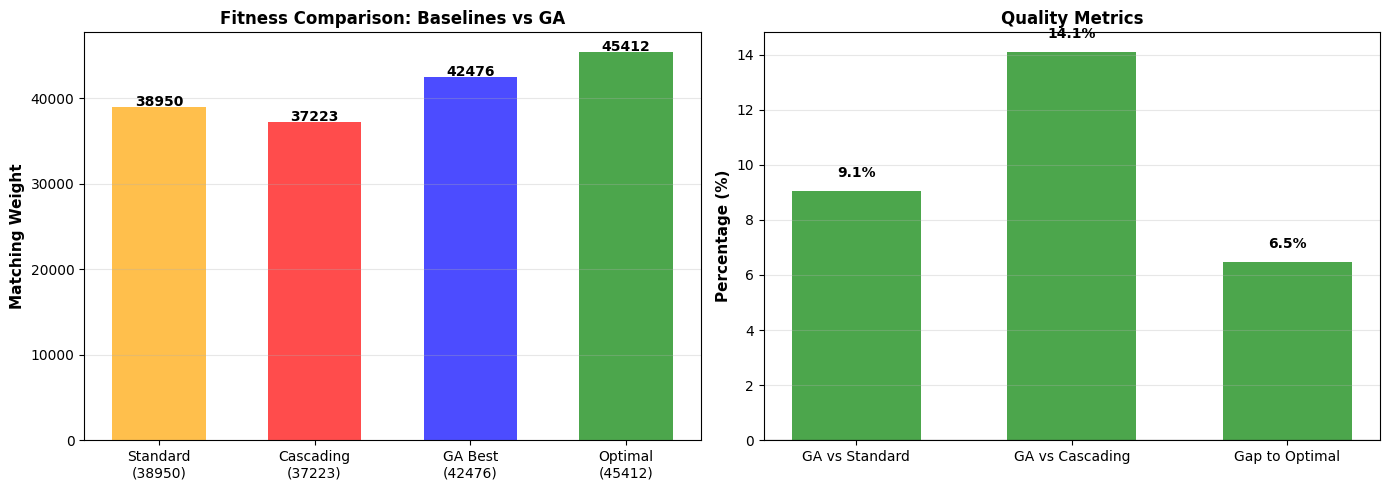

In [10]:
# Create comparison visualization with both baselines
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Fitness comparison (all three)
values = [baseline, baseline_cascading, best, optimal]
labels = [f'Standard\n({baseline:.0f})', f'Cascading\n({baseline_cascading:.0f})', f'GA Best\n({best:.0f})', f'Optimal\n({optimal:.0f})']
colors = ['orange', 'red', 'blue', 'green']

axes[0].bar(labels, values, color=colors, alpha=0.7, width=0.6)
axes[0].set_ylabel('Matching Weight', fontweight='bold', fontsize=11)
axes[0].set_title('Fitness Comparison: Baselines vs GA', fontweight='bold', fontsize=12)
axes[0].grid(True, alpha=0.3, axis='y')
for i, v in enumerate(values):
    axes[0].text(i, v + 100, f"{v:.0f}", ha='center', fontweight='bold', fontsize=10)

# Plot 2: Quality metrics (GA vs both baselines)
metrics = ['GA vs Standard', 'GA vs Cascading', 'Gap to Optimal']
improvement_cascading = ((best - baseline_cascading) / baseline_cascading * 100)
values_metrics = [improvement, improvement_cascading, gap]
colors_metrics = ['green' if v > 0 else 'red' for v in values_metrics]

bars = axes[1].bar(metrics, values_metrics, color=colors_metrics, alpha=0.7, width=0.6)
axes[1].set_ylabel('Percentage (%)', fontweight='bold', fontsize=11)
axes[1].set_title('Quality Metrics', fontweight='bold', fontsize=12)
axes[1].axhline(y=0, color='black', linestyle='-', linewidth=0.8)
axes[1].grid(True, alpha=0.3, axis='y')
for i, v in enumerate(values_metrics):
    offset = 0.5 if v > 0 else -0.5
    axes[1].text(i, v + offset, f"{v:.1f}%", ha='center', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()

## 10. Visualization: Performance Metrics

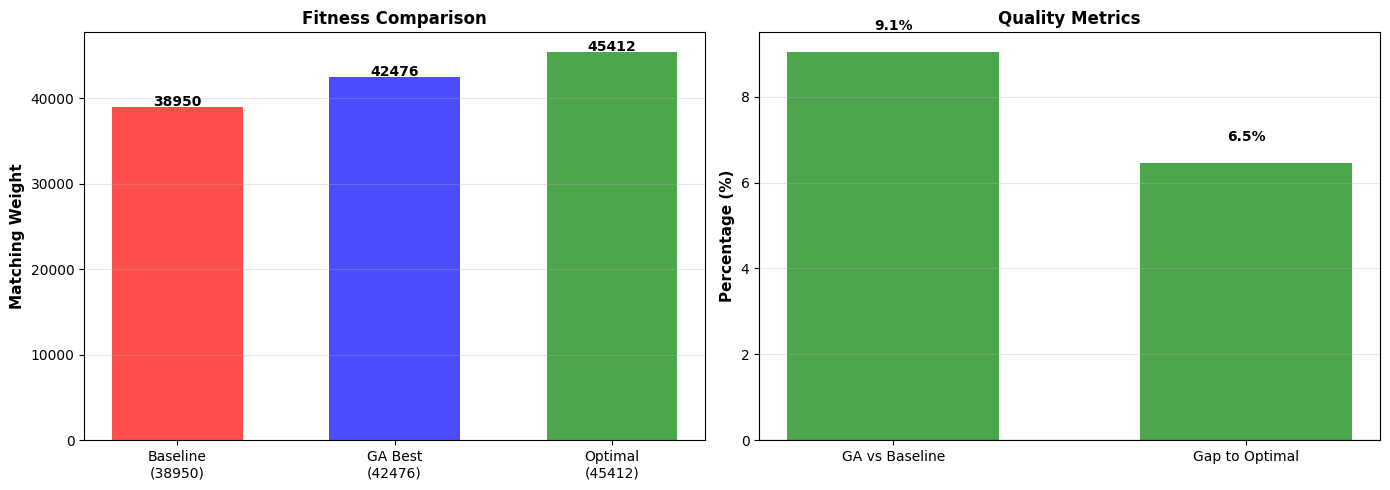

In [11]:
# Create comparison visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Fitness comparison
values = [baseline, best, optimal]
labels = [f'Baseline\n({baseline:.0f})', f'GA Best\n({best:.0f})', f'Optimal\n({optimal:.0f})']
colors = ['red', 'blue', 'green']

axes[0].bar(labels, values, color=colors, alpha=0.7, width=0.6)
axes[0].set_ylabel('Matching Weight', fontweight='bold', fontsize=11)
axes[0].set_title('Fitness Comparison', fontweight='bold', fontsize=12)
axes[0].grid(True, alpha=0.3, axis='y')
for i, v in enumerate(values):
    axes[0].text(i, v + 100, f"{v:.0f}", ha='center', fontweight='bold', fontsize=10)

# Plot 2: Quality metrics
metrics = ['GA vs Baseline', 'Gap to Optimal']
values_metrics = [improvement, gap]
colors_metrics = ['green' if v > 0 else 'red' for v in values_metrics]

bars = axes[1].bar(metrics, values_metrics, color=colors_metrics, alpha=0.7, width=0.6)
axes[1].set_ylabel('Percentage (%)', fontweight='bold', fontsize=11)
axes[1].set_title('Quality Metrics', fontweight='bold', fontsize=12)
axes[1].axhline(y=0, color='black', linestyle='-', linewidth=0.8)
axes[1].grid(True, alpha=0.3, axis='y')
for i, v in enumerate(values_metrics):
    offset = 0.5 if v > 0 else -0.5
    axes[1].text(i, v + offset, f"{v:.1f}%", ha='center', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()

## 11. Visualization: Comprehensive Analysis

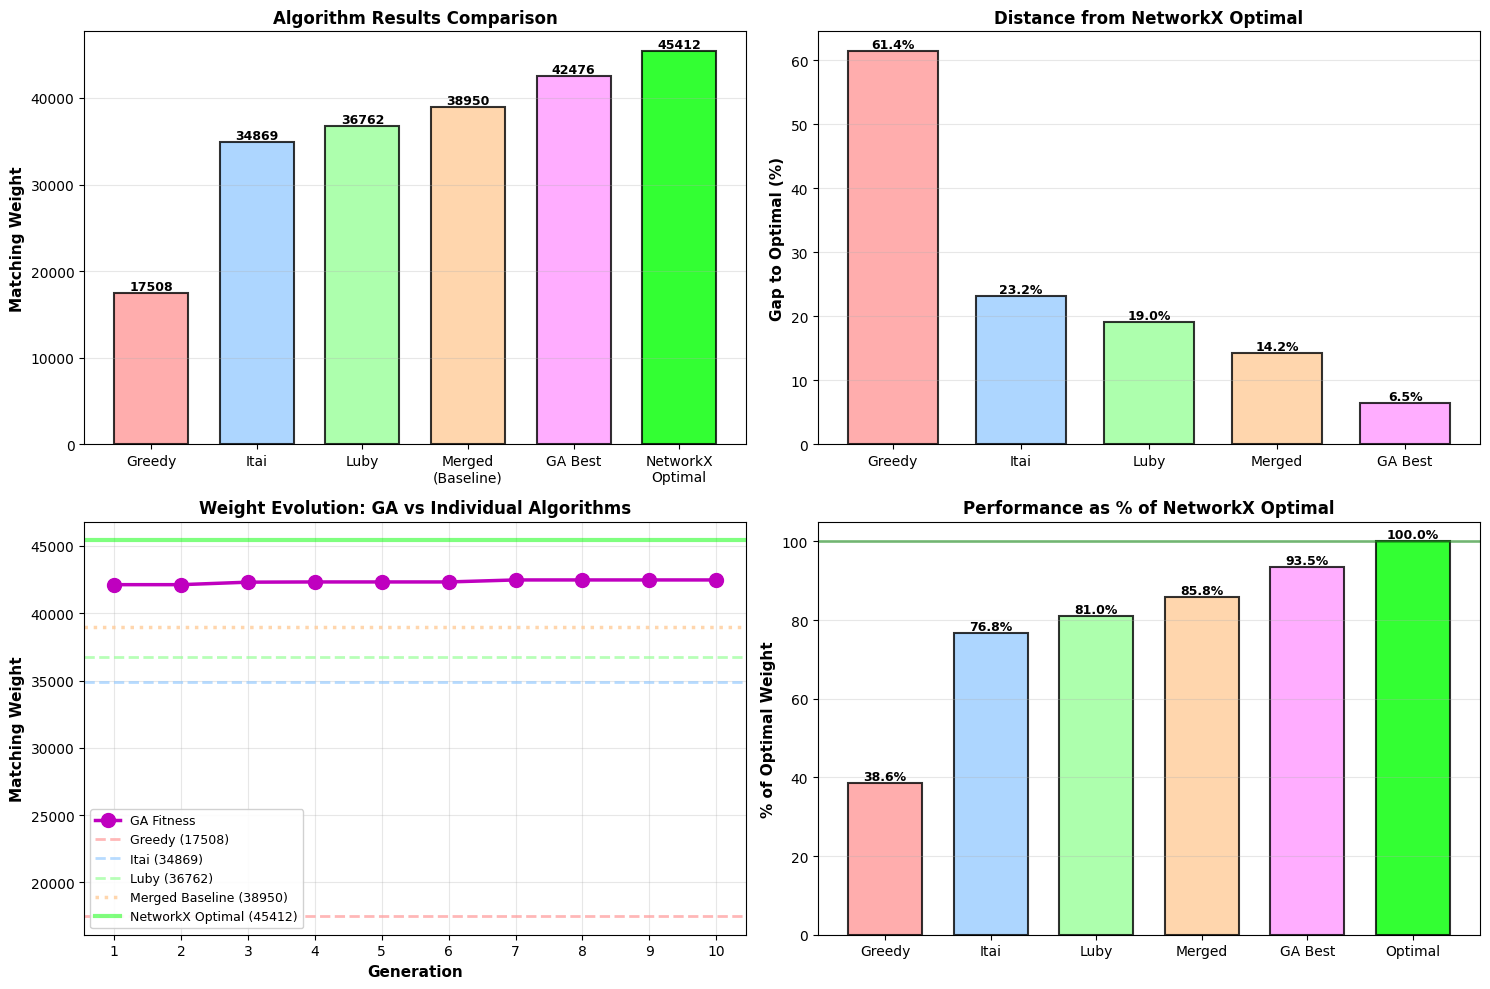

In [12]:
# Create comprehensive comparison visualization
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Plot 1: Individual algorithm weights vs baselines
ax = axes[0, 0]
algorithms = ['Greedy', 'Itai', 'Luby', 'Merged\n(Baseline)', 'GA Best', 'NetworkX\nOptimal']
weights = [greedy_weight, itai_weight, luby_weight, baseline, best, optimal]
colors_alg = ['#FF9999', '#99CCFF', '#99FF99', '#FFCC99', '#FF99FF', '#00FF00']

bars = ax.bar(algorithms, weights, color=colors_alg, alpha=0.8, width=0.7, edgecolor='black', linewidth=1.5)
ax.set_ylabel('Matching Weight', fontweight='bold', fontsize=11)
ax.set_title('Algorithm Results Comparison', fontweight='bold', fontsize=12)
ax.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for i, (bar, weight) in enumerate(zip(bars, weights)):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{weight:.0f}',
            ha='center', va='bottom', fontweight='bold', fontsize=9)

# Plot 2: Gap to Optimal
ax = axes[0, 1]
gaps = [greedy_gap, itai_gap, luby_gap, baseline_gap, ga_gap]
gap_labels = ['Greedy', 'Itai', 'Luby', 'Merged', 'GA Best']
colors_gap = ['#FF9999', '#99CCFF', '#99FF99', '#FFCC99', '#FF99FF']

bars = ax.bar(gap_labels, gaps, color=colors_gap, alpha=0.8, width=0.7, edgecolor='black', linewidth=1.5)
ax.set_ylabel('Gap to Optimal (%)', fontweight='bold', fontsize=11)
ax.set_title('Distance from NetworkX Optimal', fontweight='bold', fontsize=12)
ax.grid(True, alpha=0.3, axis='y')

# Add value labels
for bar, gap in zip(bars, gaps):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{gap:.1f}%',
            ha='center', va='bottom', fontweight='bold', fontsize=9)

# Plot 3: Weight evolution across GA generations (with algorithm baselines)
ax = axes[1, 0]
gens = list(range(1, len(fitness_history) + 1))

# Plot GA progression
ax.plot(gens, fitness_history, 'mo-', linewidth=2.5, markersize=10, label='GA Fitness', zorder=5)

# Add algorithm baselines
ax.axhline(y=greedy_weight, color='#FF9999', linestyle='--', linewidth=2, alpha=0.7, label=f'Greedy ({greedy_weight:.0f})')
ax.axhline(y=itai_weight, color='#99CCFF', linestyle='--', linewidth=2, alpha=0.7, label=f'Itai ({itai_weight:.0f})')
ax.axhline(y=luby_weight, color='#99FF99', linestyle='--', linewidth=2, alpha=0.7, label=f'Luby ({luby_weight:.0f})')
ax.axhline(y=baseline, color='#FFCC99', linestyle=':', linewidth=2.5, alpha=0.8, label=f'Merged Baseline ({baseline:.0f})')
ax.axhline(y=optimal, color='#00FF00', linestyle='-', linewidth=3, alpha=0.5, label=f'NetworkX Optimal ({optimal:.0f})')

ax.set_xlabel('Generation', fontsize=11, fontweight='bold')
ax.set_ylabel('Matching Weight', fontsize=11, fontweight='bold')
ax.set_title('Weight Evolution: GA vs Individual Algorithms', fontweight='bold', fontsize=12)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=9, loc='best', framealpha=0.9)
ax.set_xticks(gens)

# Plot 4: Normalized performance comparison (% relative to optimal)
ax = axes[1, 1]
performance_pct = [(w / optimal) * 100 for w in weights]
labels_perf = ['Greedy', 'Itai', 'Luby', 'Merged', 'GA Best', 'Optimal']
colors_perf = ['#FF9999', '#99CCFF', '#99FF99', '#FFCC99', '#FF99FF', '#00FF00']

bars = ax.bar(labels_perf, performance_pct, color=colors_perf, alpha=0.8, width=0.7, edgecolor='black', linewidth=1.5)
ax.axhline(y=100, color='green', linestyle='-', linewidth=2, alpha=0.5, label='Optimal (100%)')
ax.set_ylabel('% of Optimal Weight', fontweight='bold', fontsize=11)
ax.set_title('Performance as % of NetworkX Optimal', fontweight='bold', fontsize=12)
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim([0, 105])

# Add value labels
for bar, pct in zip(bars, performance_pct):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{pct:.1f}%',
            ha='center', va='bottom', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.show()

DETAILED RUNTIME ANALYSIS

Individual Component Timings:
--------------------------------------------------------------------------------
Component                                                Time
--------------------------------------------------------------------------------
NetworkX Optimal                                         1.3s
Fitness Evaluator Init                                   0.0s
Baseline (Merged)                                        1.1s
GA Cascading Baseline                                    1.0s
Individual Algos (Parallel)                              1.2s
GA Standard                                              5.7m
GA with Cascading                                        8.8m
--------------------------------------------------------------------------------
TOTAL                                                   14.6m

Runtime Breakdown by Category:
--------------------------------------------------------------------------------
Algorithm Execution          

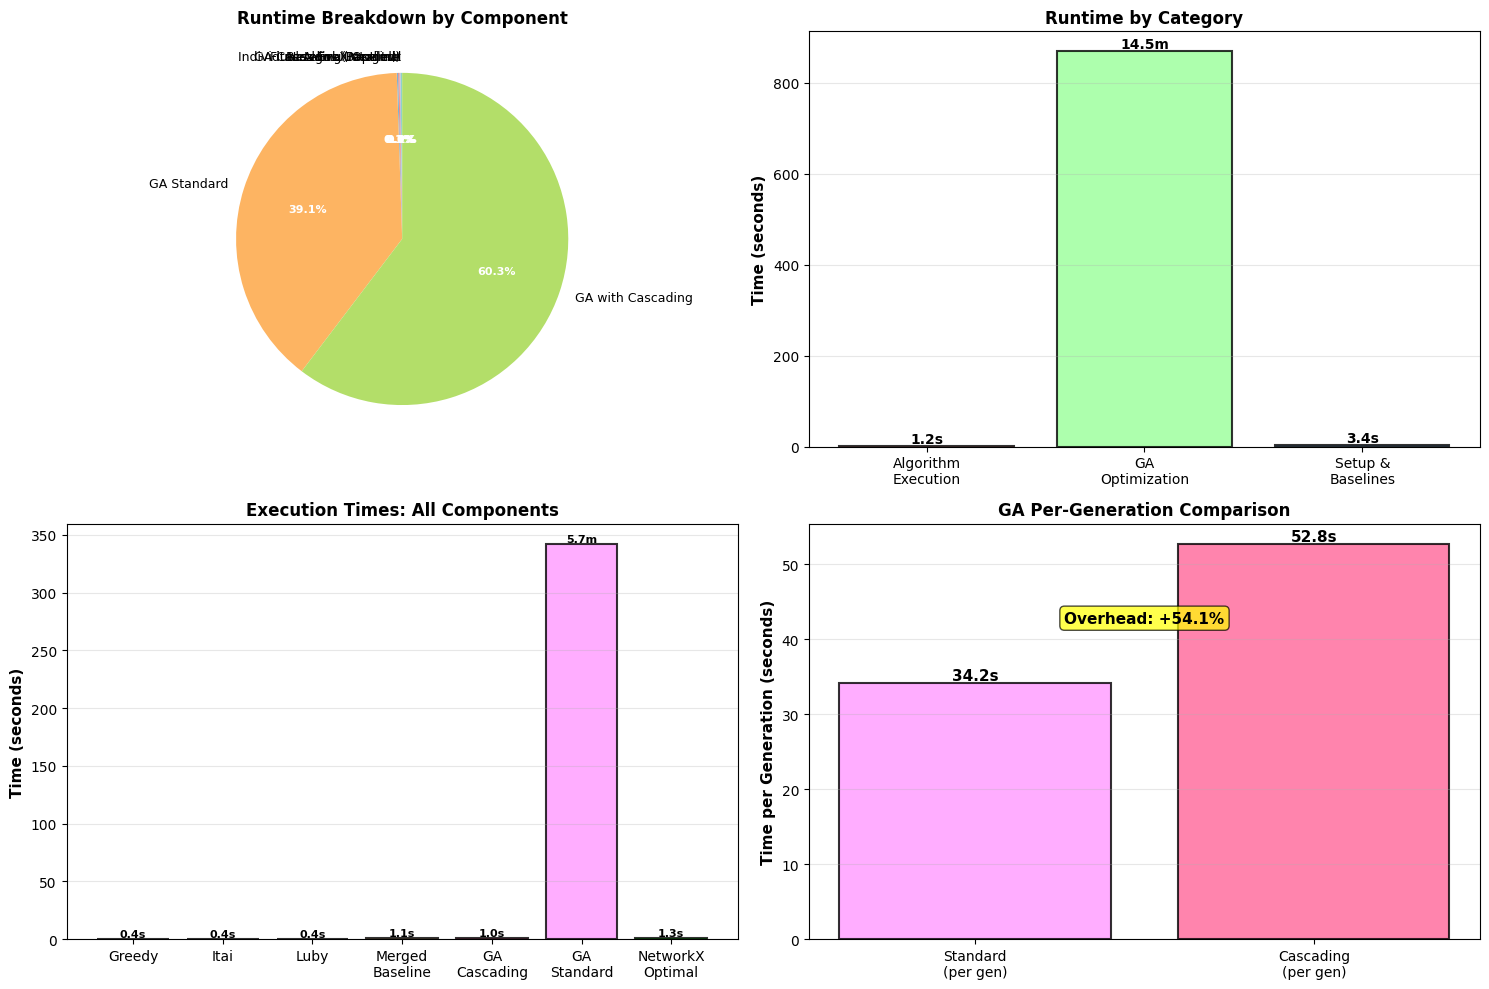

In [13]:
print("="*80)
print("DETAILED RUNTIME ANALYSIS")
print("="*80)
print()

# Create timing dictionary
timing_results = {
    'NetworkX Optimal': time_optimal,
    'Fitness Evaluator Init': time_init,
    'Baseline (Merged)': time_baseline,
    'GA Cascading Baseline': time_cascading,
    'Individual Algos (Parallel)': time_algo_parallel,
    'GA Standard': time_ga_standard,
    'GA with Cascading': time_ga,
}

# Print detailed timing breakdown
print("Individual Component Timings:")
print("-" * 80)
print(f"{'Component':<40} {'Time':>20}")
print("-" * 80)
for component, elapsed in timing_results.items():
    print(f"{component:<40} {format_time(elapsed):>20}")
print("-" * 80)
total_time = sum(timing_results.values())
print(f"{'TOTAL':<40} {format_time(total_time):>20}")
print("="*80)
print()

# Breakdown by category
print("Runtime Breakdown by Category:")
print("-" * 80)

algorithm_time = time_algo_parallel
ga_time = time_ga_standard + time_ga
setup_time = time_optimal + time_init + time_baseline + time_cascading

print(f"{'Algorithm Execution':<40} {format_time(algorithm_time):>20} ({algorithm_time/total_time*100:>5.1f}%)")
print(f"{'GA Optimization':<40} {format_time(ga_time):>20} ({ga_time/total_time*100:>5.1f}%)")
print(f"{'Setup & Baselines':<40} {format_time(setup_time):>20} ({setup_time/total_time*100:>5.1f}%)")
print("-" * 80)
print(f"{'TOTAL':<40} {format_time(total_time):>20} ({100:>5.1f}%)")
print("="*80)
print()

# Per-algorithm breakdown
print("Per-Algorithm Runtime Comparison:")
print("-" * 80)
print(f"{'Algorithm':<30} {'Weight':>15} {'Time per Exec':>20}")
print("-" * 80)
avg_algo_time = time_algo_parallel / 3  # Since we ran 3 algorithms in parallel
print(f"{'Greedy':<30} {greedy_weight:>15.0f} {format_time(avg_algo_time):>20} (parallel avg)")
print(f"{'Itai-Israeli':<30} {itai_weight:>15.0f} {format_time(avg_algo_time):>20} (parallel avg)")
print(f"{'Luby Randomized':<30} {luby_weight:>15.0f} {format_time(avg_algo_time):>20} (parallel avg)")
print("-" * 80)
print(f"{'Merged Baseline':<30} {baseline:>15.0f} {format_time(time_baseline):>20}")
print(f"{'GA Cascading Baseline':<30} {baseline_cascading:>15.0f} {format_time(time_cascading):>20}")
print("="*80)
print()

# GA iteration breakdown
print("GA Optimization Timings:")
print("-" * 80)
time_per_gen_standard = time_ga_standard / GENERATIONS
time_per_gen_cascading = time_ga / GENERATIONS

print(f"GA without Cascading:")
print(f"  Total time:       {format_time(time_ga_standard)}")
print(f"  Generations:      {GENERATIONS}")
print(f"  Time per gen:     {format_time(time_per_gen_standard)}")
print(f"  Population size:  {POPULATION_SIZE}")
print(f"  Time per indiv:   {format_time(time_per_gen_standard / POPULATION_SIZE)}")
print()

print(f"GA with Cascading:")
print(f"  Total time:       {format_time(time_ga)}")
print(f"  Generations:      {GENERATIONS}")
print(f"  Time per gen:     {format_time(time_per_gen_cascading)}")
print(f"  Population size:  {POPULATION_SIZE}")
print(f"  Time per indiv:   {format_time(time_per_gen_cascading / POPULATION_SIZE)}")
print()

cascading_overhead = ((time_per_gen_cascading - time_per_gen_standard) / time_per_gen_standard * 100)
print(f"Cascading Overhead: {cascading_overhead:+.1f}% per generation")
print("="*80)
print()

# Visualization: Runtime comparison
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Plot 1: Component breakdown (pie chart)
ax = axes[0, 0]
components = list(timing_results.keys())
times = list(timing_results.values())
colors_pie = plt.cm.Set3(range(len(components)))

wedges, texts, autotexts = ax.pie(times, labels=components, autopct='%1.1f%%', 
                                    colors=colors_pie, startangle=90, textprops={'fontsize': 9})
ax.set_title('Runtime Breakdown by Component', fontweight='bold', fontsize=12)

# Make percentage text bold
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')
    autotext.set_fontsize(8)

# Plot 2: Category breakdown (bar chart)
ax = axes[0, 1]
categories = ['Algorithm\nExecution', 'GA\nOptimization', 'Setup &\nBaselines']
category_times = [algorithm_time, ga_time, setup_time]
category_colors = ['#FF9999', '#99FF99', '#99CCFF']

bars = ax.bar(categories, category_times, color=category_colors, alpha=0.8, edgecolor='black', linewidth=1.5)
ax.set_ylabel('Time (seconds)', fontweight='bold', fontsize=11)
ax.set_title('Runtime by Category', fontweight='bold', fontsize=12)
ax.grid(True, alpha=0.3, axis='y')

# Add time labels on bars
for bar, time in zip(bars, category_times):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{format_time(time)}',
            ha='center', va='bottom', fontweight='bold', fontsize=10)

# Plot 3: Individual algorithm vs baselines
ax = axes[1, 0]
algo_names = ['Greedy', 'Itai', 'Luby', 'Merged\nBaseline', 'GA\nCascading', 'GA\nStandard', 'NetworkX\nOptimal']
algo_times = [avg_algo_time, avg_algo_time, avg_algo_time, time_baseline, time_cascading, time_ga_standard, time_optimal]
algo_colors = ['#FF9999', '#99CCFF', '#99FF99', '#FFCC99', '#FF6699', '#FF99FF', '#00FF00']

bars = ax.bar(algo_names, algo_times, color=algo_colors, alpha=0.8, edgecolor='black', linewidth=1.5)
ax.set_ylabel('Time (seconds)', fontweight='bold', fontsize=11)
ax.set_title('Execution Times: All Components', fontweight='bold', fontsize=12)
ax.grid(True, alpha=0.3, axis='y')

# Add time labels
for bar, time in zip(bars, algo_times):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{format_time(time)}',
            ha='center', va='bottom', fontweight='bold', fontsize=8, rotation=0)

# Plot 4: GA per-generation comparison
ax = axes[1, 1]
ga_methods = ['Standard\n(per gen)', 'Cascading\n(per gen)']
ga_per_gen = [time_per_gen_standard, time_per_gen_cascading]
ga_colors = ['#FF99FF', '#FF6699']

bars = ax.bar(ga_methods, ga_per_gen, color=ga_colors, alpha=0.8, edgecolor='black', linewidth=1.5)
ax.set_ylabel('Time per Generation (seconds)', fontweight='bold', fontsize=11)
ax.set_title('GA Per-Generation Comparison', fontweight='bold', fontsize=12)
ax.grid(True, alpha=0.3, axis='y')

# Add labels and overhead
for bar, time in zip(bars, ga_per_gen):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{format_time(time)}',
            ha='center', va='bottom', fontweight='bold', fontsize=11)

# Add overhead annotation
ax.text(0.5, max(ga_per_gen) * 0.8, f'Overhead: {cascading_overhead:+.1f}%',
        ha='center', fontsize=11, fontweight='bold', 
        bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.7))

plt.tight_layout()
plt.show()

## 12. Runtime Analysis: Execution Times